In [3]:
import pandas as pd
data = pd.DataFrame({
    'Age' : [22,25,29,41],
    'Income' : [30000,90000,60000,45000],
    'City' : ['Kathmandu','Pokhara','BHaktapur','Lalitpur'],
    'Has_loan' : [True,False,True,False]
})

In [4]:
data

,Age,Income,City,Has_loan
0,22,30000,Kathmandu,True
1,25,90000,Pokhara,False
2,29,60000,BHaktapur,True
3,41,45000,Lalitpur,False


## Raw Data vs Processed Data

In [5]:
raw_data = pd.DataFrame({
    'Gender' : ['M','male','Fem','female']
})
raw_data

,Gender
0,M
1,male
2,Fem
3,female


In [6]:
processed_data = raw_data.copy()
processed_data['Gender'] = processed_data['Gender'].str.lower().replace({'m':'male'})
processed_data['Gender'] = processed_data['Gender'].str.lower().replace({'fem':'female'})
processed_data

,Gender
0,male
1,male
2,female
3,female


## Numerical Features


In [7]:
df = pd.DataFrame({
    'Age' : [22,25,29,41],
    'Income' : [30000,90000,60000,45000]
    })

df

,Age,Income
0,22,30000
1,25,90000
2,29,60000
3,41,45000


In [8]:
df.dtypes

Age       int64
Income    int64
dtype: object

## Categorical Features

In [10]:
df = pd.DataFrame({
    'Department': ['HR','Finance','Tech','HR']
})
df

,Department
0,HR
1,Finance
2,Tech
3,HR


In [11]:
df.dtypes

Department    str
dtype: object

In [ ]:
df['Department'].astype('category')

,Department
0,HR
1,Finance
2,Tech
3,HR


## Ordinal Features

In [16]:
df = pd.DataFrame({
    'Experience_Level' : ['Junior','Mid','Senior','Mid']
})
df

,Experience_Level
0,Junior
1,Mid
2,Senior
3,Mid


In [17]:
df.dtypes


Experience_Level    str
dtype: object

In [18]:
mapping = {'Junior':1, 'Mid':2,'Senior':3}
df['Encoded_Level'] = df['Experience_Level'].map(mapping)
df

,Experience_Level,Encoded_Level
0,Junior,1
1,Mid,2
2,Senior,3
3,Mid,2


## Binary features

In [19]:
df = pd.DataFrame({
    'Has_loan' :[True,False,True, False]
})
df

,Has_loan
0,True
1,False
2,True
3,False


In [20]:
df.dtypes

Has_loan    bool
dtype: object

## Date and time Features

In [22]:
df = pd.DataFrame({
    'Order_Date': pd.to_datetime(['2023-01-01','2023-01-02','2023-01-03','2023-01-04']) 


})
df.dtypes

Order_Date    datetime64[us]
dtype: object

In [23]:
df

,Order_Date
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04


In [26]:
df['Day'] = df['Order_Date'].dt.day
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year
df['Weekday'] = df['Order_Date'].dt.day_name()
df

,Order_Date,Day,Month,Year,Weekday
0,2023-01-01,1,1,2023,Sunday
1,2023-01-02,2,1,2023,Monday
2,2023-01-03,3,1,2023,Tuesday
3,2023-01-04,4,1,2023,Wednesday


## Text Features


In [28]:
df = pd.DataFrame({
    'Review' : ['Amazing Product and fast delivery','Poor quality and bad packaging']
})
df['Wordcount'] = df['Review'].apply(lambda x: len(x.split()))
df['Charcount'] = df['Review'].apply(lambda x: len(x))
df

,Review,Wordcount,Charcount
0,Amazing Product and fast delivery,5,33
1,Poor quality and bad packaging,5,30


## Image and Signal Data

In [44]:
from skimage import data
import matplotlib.pyplot as plt
import numpy as np

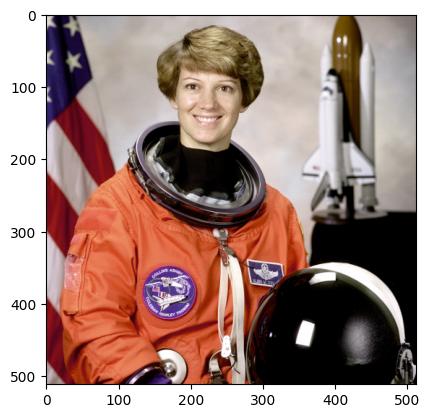

In [45]:
image= data.astronaut()
plt.imshow(image)

In [46]:
image.shape

(512, 512, 3)

In [47]:
image.ndim

3

In [48]:
arr1 = np.array([[1,2],[2,3],[3,4],[5,6]])
arr1

array([[1, 2],
       [2, 3],
       [3, 4],
       [5, 6]])

In [49]:
arr1.ndim

2

In [50]:
arr1.shape

(4, 2)

In [52]:
arr1.shape[0]

4

In [57]:
df = pd.DataFrame(
    arr1.reshape(arr1.shape[0],-1))
df

,0,1
0,1,2
1,2,3
2,3,4
3,5,6


In [58]:
mean_pixel = np.mean(image)
std_pixel = np.std(image)
mean_pixel , std_pixel

(np.float64(114.59900410970052), np.float64(81.23036724707771))

## Feature Engineering vs Feature Extraction vs Feature Selection
- These three techniques are the core pillars of data preparation in machine learning, used to optimize raw data for predictive models.
- Feature Engineering creates new features
- Feature Extraction transforms and condenses complex data into fewer dimensions
- Feature Selection filters out the noise by dropping irrelevant or redundant data

In [68]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest , f_regression


df = pd.DataFrame({
    'x1' : [1,2,3,4],
    'x2' : [2,4,6,8],
    'y' : [10,20,30,40]
})

poly  = PolynomialFeatures(degree=2)
poly_features = poly.fit_transform(df[['x1','x2']])

selector = SelectKBest(score_func=f_regression,k=1)
selected = selector.fit_transform(df[['x1','x2']],df['y'])
poly_features , selected

(array([[ 1.,  1.,  2.,  1.,  2.,  4.],
        [ 1.,  2.,  4.,  4.,  8., 16.],
        [ 1.,  3.,  6.,  9., 18., 36.],
        [ 1.,  4.,  8., 16., 32., 64.]]),
 array([[2],
        [4],
        [6],
        [8]]))

## Date Leakage

In [69]:
from sklearn.model_selection import train_test_split

df = pd.DataFrame({
    'Age' : [22,34,53,23],
    'Income' : [30000,20000,40000,50600],
    'Approved': [0,1,1,1]
})


x = df[['Age','Income']]
y = df['Approved']
x_train, x_test ,y_train, y_test = train_test_split(x,y,test_size=0.2)
x_train.shape , x_test.shape

((3, 2), (1, 2))